In [323]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_scada = pd.read_csv('../datasets_raw/T1.csv')
df_scada.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


In [324]:
print(df_scada.shape) # how many rows and columns we have

(50530, 5)


In [325]:
print(df_scada.dtypes) # tell us what type each column is

Date/Time                         object
LV ActivePower (kW)              float64
Wind Speed (m/s)                 float64
Theoretical_Power_Curve (KWh)    float64
Wind Direction (°)               float64
dtype: object


In [326]:
df_scada['Date/Time'] = pd.to_datetime(df_scada['Date/Time'], format='%d %m %Y %H:%M')

#unifying time format part of PB-2
#noe becomes a cleaner standard format

In [327]:
print(df_scada.dtypes)
df_scada.head()

Date/Time                        datetime64[ns]
LV ActivePower (kW)                     float64
Wind Speed (m/s)                        float64
Theoretical_Power_Curve (KWh)           float64
Wind Direction (°)                      float64
dtype: object


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


In [328]:
print("Shape:", df_scada.shape)
print("\nMissing values:")
print(df_scada.isnull().sum())

Shape: (50530, 5)

Missing values:
Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64


In [329]:
print("Zero values per column:")  
print((df_scada == 0).sum())
# we are counting how many "0" values there are per column
# LV Activepower and THeoretical_Power_Curve by far has the most!

print("\nPercentage of zeros:")
print((df_scada == 0).sum() / len(df_scada) * 100)

Zero values per column:
Date/Time                            0
LV ActivePower (kW)              10781
Wind Speed (m/s)                    10
Theoretical_Power_Curve (KWh)     7749
Wind Direction (°)                  75
dtype: int64

Percentage of zeros:
Date/Time                         0.000000
LV ActivePower (kW)              21.335840
Wind Speed (m/s)                  0.019790
Theoretical_Power_Curve (KWh)    15.335444
Wind Direction (°)                0.148427
dtype: float64


In [330]:
# Flag zero power rows
df_scada['zero_power'] = df_scada['LV ActivePower (kW)'] == 0

#True = the turbine produced zero power at that moment
#False = the turbine was producing normally

# we essentially have 10781 zero power moments in the whole dataset

# Look at the zero wind speed rows specifically
print(df_scada[df_scada['Wind Speed (m/s)'] == 0])

#here we see that there are no contradictors, when all 10 speed are zero everything else is zero so there is no sensor failure.



                Date/Time  LV ActivePower (kW)  Wind Speed (m/s)  \
1478  2018-01-11 09:50:00                  0.0               0.0   
3629  2018-01-30 16:40:00                  0.0               0.0   
14647 2018-04-17 06:50:00                  0.0               0.0   
17116 2018-05-04 13:10:00                  0.0               0.0   
20369 2018-05-27 03:50:00                  0.0               0.0   
23280 2018-06-16 15:40:00                  0.0               0.0   
24819 2018-06-27 14:00:00                  0.0               0.0   
36045 2018-09-13 19:50:00                  0.0               0.0   
46598 2018-12-04 14:50:00                  0.0               0.0   
46637 2018-12-04 21:30:00                  0.0               0.0   

       Theoretical_Power_Curve (KWh)  Wind Direction (°)  zero_power  
1478                             0.0                 0.0        True  
3629                             0.0                 0.0        True  
14647                            0.0  

In [331]:
print("Negative power rows:", (df_scada['LV ActivePower (kW)'] < 0).sum())  
#57 rows where the turbine shows negative power output. This is physically impossible — a turbine cannot produce negative electricity.
#it will have to be removed

print("Wind speed above 35 m/s:", (df_scada['Wind Speed (m/s)'] > 35).sum())  
# this is clean there are nothing above 35 unrealistice wind speeds

print("Power above 3600 kW:", (df_scada['LV ActivePower (kW)'] > 3600).sum()) 
#From your initial exploration in the project plan, the maximum capacity was around 3,600 kW. Having 2,881 rows above that needs investigation
#but this is not an error many values are set above the threshold of 3600 but not more that 3618KW

Negative power rows: 57
Wind speed above 35 m/s: 0
Power above 3600 kW: 2881


In [332]:
# Check the actual maximum power value
print("Max power:", df_scada['LV ActivePower (kW)'].max())

# Look at the distribution of values above 3600
print("\nValues above 3600:")
print(df_scada[df_scada['LV ActivePower (kW)'] > 3600]['LV ActivePower (kW)'].describe())

Max power: 3618.73291015625

Values above 3600:
count    2881.000000
mean     3602.479592
std         1.140125
min      3600.003906
25%      3601.707031
50%      3602.566895
75%      3603.322998
max      3618.732910
Name: LV ActivePower (kW), dtype: float64


In [333]:
print("Rows before:", len(df_scada))
df_scada = df_scada[df_scada['LV ActivePower (kW)'] >= 0] # with this condition inside, we only keep the one that are True
print("Rows after:", len(df_scada))

# 50,530 minus 57 = 50,473. The 57 negative power rows have been removed.

Rows before: 50530
Rows after: 50473


In [334]:
# Set Date/Time as the index first
df_scada = df_scada.set_index('Date/Time')

#We moved the timestamp column from a regular column to the index of the dataframe. This is required for resampling
#pandas needs the time to be the index so it knows how to group the rows by hour.

# Resample to hourly using mean
df_scada_hourly = df_scada.resample('1h').agg({
    'LV ActivePower (kW)': 'mean',
    'Wind Speed (m/s)': 'mean',
    'Theoretical_Power_Curve (KWh)': 'mean',
    'Wind Direction (°)': 'mean',
    'zero_power': 'sum'  # counts how many zero power readings were in that hour
})

#This grouped all 10-minute rows that belong to the same hour together and calculated the mean of each column within that hour. 
#So for example the 6 rows between 00:00 and 00:50 became one single row at 00:00.
#For zero_power specifically we used sum instead of mean
#so it tells us how many of the 6 ten-minute readings within that hour had zero power, which is more useful than an average.

print(df_scada_hourly.shape)
df_scada_hourly.head()

(8760, 5)


,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),zero_power
Date/Time,,,,,
2018-01-01 00:00:00,390.480362,5.506868,472.402227,267.118632,0
2018-01-01 01:00:00,460.537125,5.644205,513.418408,258.945546,0
2018-01-01 02:00:00,733.655375,6.452037,788.401310,268.397466,0
2018-01-01 03:00:00,909.362081,6.811455,948.793346,256.014765,0
2018-01-01 04:00:00,1393.518188,7.748749,1406.391795,247.652468,0


In [335]:
#Each row is now one hour, and the values are the average of all 10-minute readings within that hour.

In [336]:
# Cell 11 - Convert kW to MW
df_scada_hourly['LV ActivePower (MW)'] = df_scada_hourly['LV ActivePower (kW)'] / 1000
df_scada_hourly['Theoretical_Power_Curve (MW)'] = df_scada_hourly['Theoretical_Power_Curve (KWh)'] / 1000

df_scada_hourly.head()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),zero_power,LV ActivePower (MW),Theoretical_Power_Curve (MW)
Date/Time,,,,,,,
2018-01-01 00:00:00,390.480362,5.506868,472.402227,267.118632,0,0.390480,0.472402
2018-01-01 01:00:00,460.537125,5.644205,513.418408,258.945546,0,0.460537,0.513418
2018-01-01 02:00:00,733.655375,6.452037,788.401310,268.397466,0,0.733655,0.788401
2018-01-01 03:00:00,909.362081,6.811455,948.793346,256.014765,0,0.909362,0.948793
2018-01-01 04:00:00,1393.518188,7.748749,1406.391795,247.652468,0,1.393518,1.406392


In [337]:
#saving the cleaned data
df_scada_hourly.to_csv('../datasets/scada_clean.csv')
print("Saved successfully!")
print("Final shape:", df_scada_hourly.shape)

Saved successfully!
Final shape: (8760, 7)


In [338]:
stats = df_scada_hourly[['LV ActivePower (kW)', 
                          'Wind Speed (m/s)', 
                          'Theoretical_Power_Curve (KWh)',
                          'Wind Direction (°)']].agg(['min', 'max', 'mean', 'median', 'std'])

print(stats.round(2))

        LV ActivePower (kW)  Wind Speed (m/s)  Theoretical_Power_Curve (KWh)  \
min                    0.00              0.00                           0.00   
max                 3604.41             23.75                        3600.00   
mean                1305.57              7.55                        1490.56   
median               846.70              7.10                        1087.52   
std                 1291.31              4.17                        1345.06   

        Wind Direction (°)  
min                   0.00  
max                 357.27  
mean                123.67  
median               75.46  
std                  88.22  


In [339]:
# Cell 14 - Save stats and add observations
print("=== SCADA Dataset Statistics Summary ===\n")
print(stats.round(2).to_string())

print("\n=== Notable Observations ===")
print("1. Turbine rated capacity is approximately 3600 kW, confirmed by both actual and theoretical max")
print("2. Mean power (1305 kW) is significantly higher than median (846 kW), indicating right skewed distribution")
print("3. Wind speed mean of 7.55 m/s is close to turbine cut-in speed")
print("4. High power std of 1291 kW shows highly variable production throughout 2018")
print("5. Actual max power (3604 kW) slightly exceeds theoretical max (3600 kW) due to sensor variation")

=== SCADA Dataset Statistics Summary ===

        LV ActivePower (kW)  Wind Speed (m/s)  Theoretical_Power_Curve (KWh)  Wind Direction (°)
min                    0.00              0.00                           0.00                0.00
max                 3604.41             23.75                        3600.00              357.27
mean                1305.57              7.55                        1490.56              123.67
median               846.70              7.10                        1087.52               75.46
std                 1291.31              4.17                        1345.06               88.22

=== Notable Observations ===
1. Turbine rated capacity is approximately 3600 kW, confirmed by both actual and theoretical max
2. Mean power (1305 kW) is significantly higher than median (846 kW), indicating right skewed distribution
3. Wind speed mean of 7.55 m/s is close to turbine cut-in speed
4. High power std of 1291 kW shows highly variable production throughout 2018


In [340]:
# Check gap sizes - how many consecutive NaN rows are there?
df_scada_hourly['gap'] = df_scada_hourly['Wind Speed (m/s)'].isnull()
df_scada_hourly['gap_group'] = (df_scada_hourly['gap'] != df_scada_hourly['gap'].shift()).cumsum()

gap_sizes = df_scada_hourly[df_scada_hourly['gap']].groupby('gap_group').size()
print("Gap size distribution:")
print(gap_sizes.value_counts().sort_index())

Gap size distribution:
1      2
2      4
3      1
5      1
6      1
7      1
11     1
86     1
90     1
103    1
Name: count, dtype: int64


In [341]:
cols_to_fix = ['LV ActivePower (kW)', 'Wind Speed (m/s)', 
               'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)',
               'LV ActivePower (MW)', 'Theoretical_Power_Curve (MW)']

# Interpolate small gaps up to 7 hours
df_scada_hourly[cols_to_fix] = df_scada_hourly[cols_to_fix].interpolate(
    method='time', limit=7)

# Drop the large gaps
df_scada_hourly = df_scada_hourly.dropna(subset=cols_to_fix)

print("Remaining missing values:")
print(df_scada_hourly[cols_to_fix].isnull().sum())
print("\nFinal shape:", df_scada_hourly.shape)

Remaining missing values:
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
LV ActivePower (MW)              0
Theoretical_Power_Curve (MW)     0
dtype: int64

Final shape: (8498, 9)


In [342]:
df_scada_hourly.to_csv('../datasets/scada_clean.csv')
print("Saved newer version!")
print("Final shape:", df_scada_hourly.shape)

Saved newer version!
Final shape: (8498, 9)


In [343]:
# Drop the helper columns
df_scada_hourly = df_scada_hourly.drop(columns=['gap', 'gap_group'])

# Save final version
df_scada_hourly.to_csv('../datasets/scada_clean.csv')

print("Final shape:", df_scada_hourly.shape)
print("Columns:", list(df_scada_hourly.columns))
print("Done!")

Final shape: (8498, 7)
Columns: ['LV ActivePower (kW)', 'Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)', 'zero_power', 'LV ActivePower (MW)', 'Theoretical_Power_Curve (MW)']
Done!


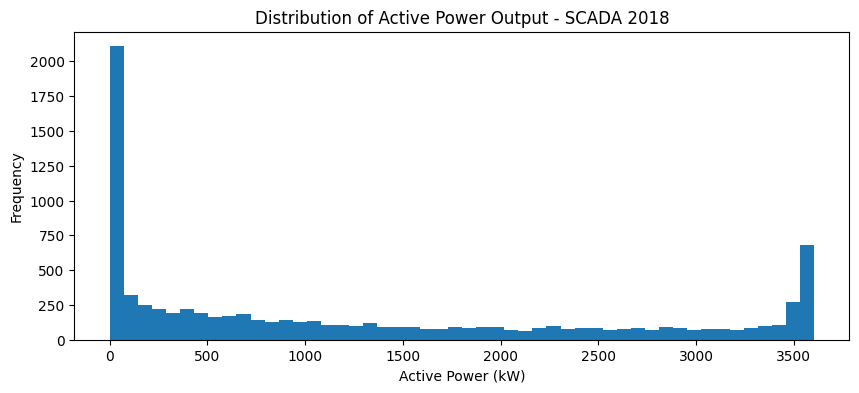

In [344]:
plt.figure(figsize=(10,4))
plt.hist(df_scada_hourly['LV ActivePower (kW)'], bins=50)
plt.title('Distribution of Active Power Output - SCADA 2018')
plt.xlabel('Active Power (kW)')
plt.ylabel('Frequency')
plt.savefig('scada_power_distribution.png')
plt.show()

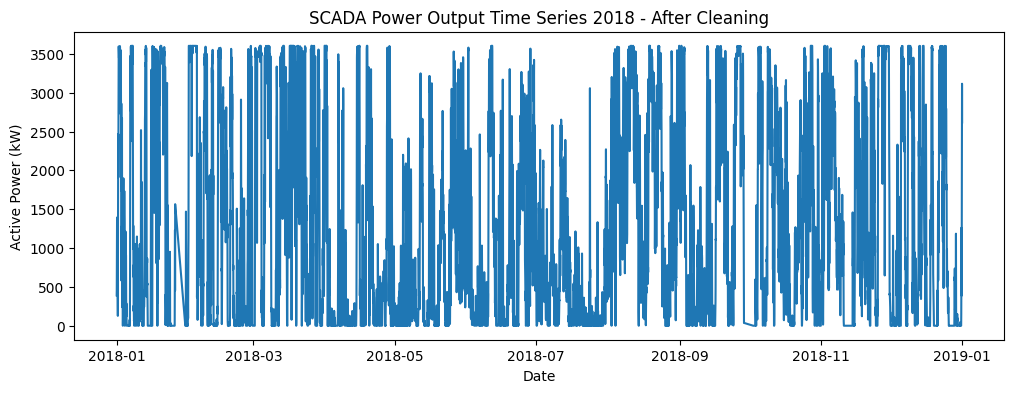

In [345]:
plt.figure(figsize=(12,4))
plt.plot(df_scada_hourly.index, df_scada_hourly['LV ActivePower (kW)'])
plt.title('SCADA Power Output Time Series 2018 - After Cleaning')
plt.xlabel('Date')
plt.ylabel('Active Power (kW)')
plt.savefig('scada_timeseries.png')
plt.show()

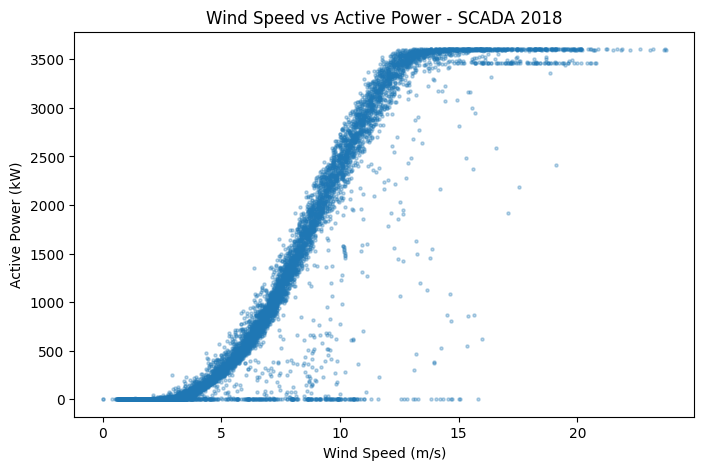

In [346]:
plt.figure(figsize=(8,5))
plt.scatter(df_scada_hourly['Wind Speed (m/s)'], 
            df_scada_hourly['LV ActivePower (kW)'], 
            alpha=0.3, s=5)
plt.title('Wind Speed vs Active Power - SCADA 2018')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Active Power (kW)')
plt.savefig('scada_power_curve.png')
plt.show()

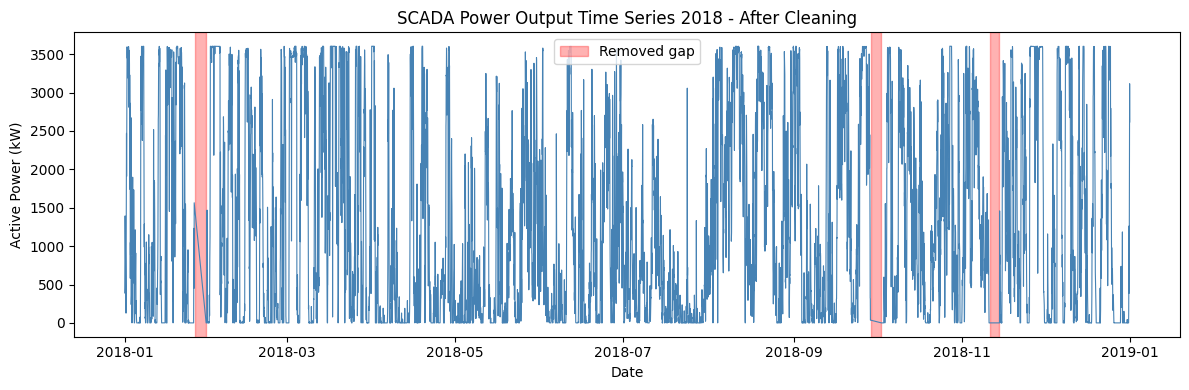

In [347]:
import matplotlib.patches as mpatches

plt.figure(figsize=(12,4))
plt.plot(df_scada_hourly.index, df_scada_hourly['LV ActivePower (kW)'], 
         color='steelblue', linewidth=0.8)

# Correctly positioned gaps
plt.axvspan(pd.Timestamp('2018-01-26 13:00'), pd.Timestamp('2018-01-30 14:00'), 
            color='red', alpha=0.3, label='Removed gap')
plt.axvspan(pd.Timestamp('2018-09-29 04:00'), pd.Timestamp('2018-10-02 16:00'), 
            color='red', alpha=0.3)
plt.axvspan(pd.Timestamp('2018-11-11 04:00'), pd.Timestamp('2018-11-14 12:00'), 
            color='red', alpha=0.3)

plt.title('SCADA Power Output Time Series 2018 - After Cleaning')
plt.xlabel('Date')
plt.ylabel('Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.savefig('scada_timeseries.png')
plt.show()